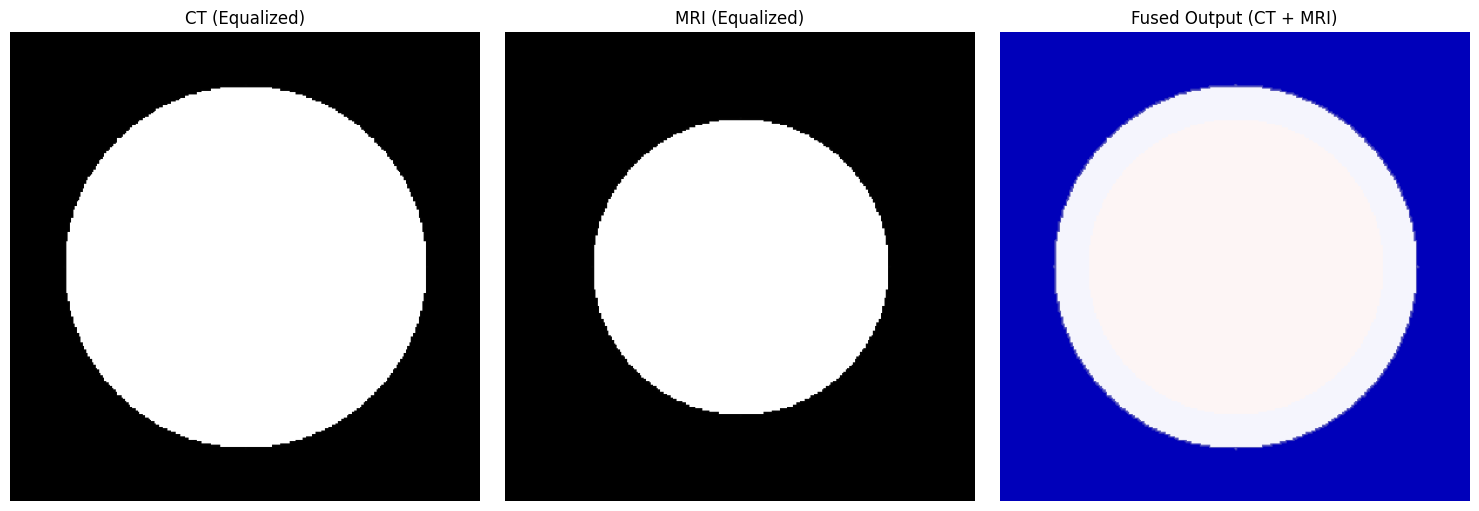

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load both scans as grayscale
ct = cv2.imread('ct.jpg', cv2.IMREAD_GRAYSCALE)
mri = cv2.imread('mri.jpg', cv2.IMREAD_GRAYSCALE)

# make both same size
ct = cv2.resize(ct, (400, 400))
mri = cv2.resize(mri, (400, 400))

# equalize both for better contrast
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)

# apply color maps
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)

ct_color_rgb = cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)
mri_color_rgb = cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)

# weighted fusion - CT heavier for edges, MRI lighter for tissue
fused = cv2.addWeighted(ct_color_rgb, 0.7, mri_color_rgb, 0.3, 0)

# log transform to recover dark areas
fused_float = fused.astype(np.float64)
c = 255 / np.log(1 + np.max(fused_float))
log_fused = c * np.log(1 + fused_float)
log_fused = np.uint8(log_fused)

# gamma correction for midtones
gamma = 0.8
gamma_fused = np.array(255 * (log_fused / 255.0) ** gamma, dtype=np.uint8)

# side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ct_eq, cmap='gray')
axes[0].set_title('CT (Equalized)')
axes[0].axis('off')

axes[1].imshow(mri_eq, cmap='gray')
axes[1].set_title('MRI (Equalized)')
axes[1].axis('off')

axes[2].imshow(gamma_fused)
axes[2].set_title('Fused Output (CT + MRI)')
axes[2].axis('off')

plt.tight_layout()
plt.show()